# Dynamic Interference-Tunneling QACO for Dynamic VRP - V2

This is a **classical quantum-inspired** algorithm. Complex amplitudes, interference, and a tunneling-inspired acceptance rule are search mechanisms executed on a conventional computer; this notebook makes no quantum-speedup claim.

## What's New in V2

- **Inherited:** seeded synthetic traffic (drift, shocks, volatility), ACO pheromone memory, complex amplitudes, explicit cross-term logging, adaptive controls, diversity/entropy metrics, ablation logic, and plotting intent from V1.
- **Fixed:** V1's periodic age phase is replaced by a non-periodic *traffic-relationship phase*. Current cost and edge-level change determine whether traffic reinforces or opposes history; a bad current edge gives a phase near π and cannot become constructive merely by aging.
- **Added:** a genuine capacitated multi-vehicle VRP representation, demand/capacity and optional time-window checks, 2-opt/relocate/swap/cross-route local search, barrier-aware tunneling acceptance, traffic-aware candidate lists, adaptive evaporation, partial reconstruction after localized shocks, and a classical score-fusion interference control.
- **Interference:** `a_history + a_traffic` is measured after the isolated `2 Re(conj(a_history) * a_traffic)` cross-term is logged per decision.
- **Tunneling:** feasible nonlocal transitions can cross a bounded fitness barrier; worse candidates are accepted probabilistically according to a decaying/adaptive exploration temperature, not described as physical tunneling.
- **Controller:** stagnation, diversity, volatility, and local-search failures jointly adjust traffic emphasis, candidate width, local-search budget, evaporation, and tunneling probability.
- **Dynamic VRP:** changed edges identify affected vehicle routes. Unaffected routes are frozen while affected customer portions are removed and reconstructed, instead of restarting all vehicles.

## 0. Setup, reproducibility, and fair benchmark conditions

All variants share the same instance generator, seeds, feasibility rules, objectives, ants, iteration budget, candidate-list policy bounds, and local-search operator suite. The small default uses 12 customers and completes quickly; increase the problem and budget only after validation. A high-budget reference run is frozen before convergence comparisons, and is called an **empirical reference**, not a published BKS.

In [32]:
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Callable, Mapping, Sequence
import copy, math, time
import numpy as np
import matplotlib.pyplot as plt

CFG: dict[str, object] = {
    'seed': 17,
    'n_customers': 18,
    'n_vehicles': 5,
    'capacity': 12.0,

    'num_ants': 14,
    'iterations': 160,

    'candidate_k': 8,
    'candidate_k_min': 4,
    'candidate_k_max': 14,

    'alpha': 1.0,
    'beta': 2.5,

    'rho': 0.18,
    'rho_min': 0.10,
    'rho_max': 0.45,
    'deposit': 12.0,

    'history_weight': 1.0,
    'traffic_weight': 0.45,
    'positive_change_sensitivity': 3.0,

    'traffic_drift': 0.22,
    'shock_strength': 4.0,
    'shock_iterations': (40, 85, 130),
    'shock_edge_fraction': 0.25,
    'shock_duration': 40,

    'volatility_reconstruct_threshold': 0.02,
    'reconstruct_cooldown': 3,

    'S_max': 14,
    'tunnel_temperature': 0.18,
    'tunnel_barrier_max': 0.18,

    'objective_distance': 0.25,
    'objective_time': 1.0,
    'objective_congestion': 1.75,
    'objective_vehicles': 0.10,
    'penalty': 10_000.0,

    'local_search_moves': 2,
    'time_windows': False,
}

CFG.update({
    'phase_congestion_scale': 1.0,
    'phase_worsening_scale': 0.35,
    'phase_max_fraction': 0.85,
    'interference_baseline': 0.15,
})

FLAGS = {
    'interference_on': False,
    'tunneling_on': False,
    'local_search_on': False,
    'adaptive_on': False,
    'dynamic_on': False,
    'classical_fusion_control': False,
    'partial_reconstruct_on': False,
}

## 1. Dynamic capacitated VRP benchmark

A solution is a list of depot routes, such as `[[0, 5, 3, 0], [0, 1, 7, 0]]`. The complete Euclidean road network is held as matrices so traffic updates and edge-level deltas are explicit. Feasibility includes one visit per customer, vehicle capacity, and optional time windows.

In [33]:
Route = list[int]
Solution = list[Route]

@dataclass
class DynamicVRP:
    """Capacitated multi-vehicle dynamic VRP instance with matrix traffic state."""
    cfg: Mapping[str, object]
    coords: np.ndarray = field(init=False); demand: np.ndarray = field(init=False)
    base: np.ndarray = field(init=False); weight: np.ndarray = field(init=False); previous: np.ndarray = field(init=False)
    tw_open: np.ndarray = field(init=False); tw_close: np.ndarray = field(init=False)
    changed_edges: set[tuple[int, int]] = field(default_factory=set, init=False)
    active_shocks: dict[tuple[int, int], int] = field(default_factory=dict, init=False)

    def __post_init__(self) -> None:
        self.active_shocks = {}
        rng = np.random.default_rng(int(self.cfg['seed']))
        n = int(self.cfg['n_customers']) + 1
        self.coords = rng.uniform(0, 1, (n, 2)); self.coords[0] = (0.5, 0.5)
        self.base = np.linalg.norm(self.coords[:, None] - self.coords[None, :], axis=2) + np.eye(n)
        np.fill_diagonal(self.base, 0.0); self.weight = self.base.copy(); self.previous = self.weight.copy()
        self.demand = np.r_[0.0, rng.integers(1, 4, n - 1)].astype(float)
        # Always feasible under the default total fleet capacity; optional broad time windows.
        self.tw_open = np.zeros(n); self.tw_close = np.full(n, np.inf)
        if bool(self.cfg['time_windows']): self.tw_close[1:] = rng.uniform(3.0, 6.0, n - 1)
        self.phase = rng.uniform(0, 2*np.pi, (n, n)); self.phase = (self.phase + self.phase.T) / 2

    def advance(self,iteration: int,dynamic: bool,prefer_edges: set[tuple[int, int]] | None = None) -> tuple[float, np.ndarray]:
        """Apply smooth drift plus persistent localized shocks."""
        self.previous = self.weight.copy()
        n = len(self.weight)

        if not dynamic:
            self.weight = self.base.copy()
            self.changed_edges = set()
            delta = self.weight - self.previous
            volatility = float(np.linalg.norm(delta) / (np.linalg.norm(self.previous) + 1e-12))
            return volatility, delta

        factor = 1.0 + float(self.cfg['traffic_drift']) * np.sin(0.07 * iteration + self.phase)
        factor = (factor + factor.T) / 2.0

        if iteration in self.cfg['shock_iterations']:
            rng = np.random.default_rng(int(self.cfg['seed']) + iteration)
            all_pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]

            preferred = []
            if prefer_edges:
                for e in prefer_edges:
                    e = tuple(sorted(e))
                    if e[0] != e[1] and 0 <= e[0] < n and 0 <= e[1] < n:
                        preferred.append(e)

            m = max(2, int(len(all_pairs) * float(self.cfg['shock_edge_fraction'])))
            duration = int(self.cfg.get('shock_duration', 12))

            if len(preferred) >= 2:
                chosen_idx = rng.choice(len(preferred), size=min(m, len(preferred)), replace=False)
                chosen = [preferred[int(k)] for k in chosen_idx]
            else:
                chosen_idx = rng.choice(len(all_pairs), size=m, replace=False)
                chosen = [all_pairs[int(k)] for k in chosen_idx]

            for e in chosen:
                self.active_shocks[tuple(sorted(e))] = iteration + duration

        # Remove expired shocks.
        self.active_shocks = {edge: expiry for edge, expiry in self.active_shocks.items() if expiry > iteration}

        self.changed_edges = set(self.active_shocks.keys())

        shock = np.zeros_like(self.base)
        for i, j in self.changed_edges:
            shock[i, j] = shock[j, i] = float(self.cfg['shock_strength'])

        self.weight = self.base * np.maximum(0.05, factor + shock)
        np.fill_diagonal(self.weight, 0.0)

        delta = self.weight - self.previous
        volatility = float(np.linalg.norm(delta) / (np.linalg.norm(self.previous) + 1e-12))

        return volatility, delta

    def feasible_route(self, route: Route) -> bool:
        """Check depot closure, capacity, and optional arrival-window feasibility."""
        if len(route) < 2 or route[0] != 0 or route[-1] != 0: return False
        if sum(self.demand[c] for c in route[1:-1]) > float(self.cfg['capacity']) + 1e-9: return False
        clock = 0.0
        for i, j in zip(route[:-1], route[1:]):
            clock += self.weight[i, j]
            if j and (clock < self.tw_open[j] or clock > self.tw_close[j]): return False
        return True

    def feasible(self, solution: Solution) -> bool:
        """Require each customer exactly once, bounded fleet, and feasible individual routes."""
        seen = [c for r in solution for c in r[1:-1]]
        return (len(solution) <= int(self.cfg['n_vehicles']) and sorted(seen) == list(range(1, len(self.demand)))
                and len(set(seen)) == len(seen) and all(self.feasible_route(r) for r in solution))

    def objective_parts(self, solution: Solution) -> dict[str, float]:
        """Evaluate weighted distance, travel time, congestion, vehicle count, and violations."""
        distance = sum(self.base[i,j] for r in solution for i,j in zip(r[:-1], r[1:]))
        travel = sum(self.weight[i,j] for r in solution for i,j in zip(r[:-1], r[1:]))
        congestion = sum(max(self.weight[i,j] / max(self.base[i,j],1e-12) - 1, 0) * self.base[i,j]
                         for r in solution for i,j in zip(r[:-1], r[1:]))
        violations = 0 if self.feasible(solution) else 1
        value = (float(self.cfg['objective_distance'])*distance + float(self.cfg['objective_time'])*travel +
                 float(self.cfg['objective_congestion'])*congestion + float(self.cfg['objective_vehicles'])*len(solution) +
                 float(self.cfg['penalty'])*violations)
        return {'distance': float(distance), 'travel_time': float(travel), 'congestion': float(congestion),
                'vehicles': float(len(solution)), 'violations': float(violations), 'objective': float(value)}

    def affected_route_indices(self, solution: Solution) -> list[int]:
        """Find only routes containing congestion-shocked directed/undirected legs."""
        return [k for k,r in enumerate(solution) if any(tuple(sorted((i,j))) in self.changed_edges for i,j in zip(r[:-1],r[1:]))]

## 2. Amplitudes, meaningful traffic state, and measurable interference

For a feasible transition `i -> j`, the historical score is pheromone and heuristic memory. The traffic score separately uses current travel cost and **edge-level change** `Δw`; worsening costs reduce desirability whereas improving costs can raise it. Global volatility only controls how much traffic is trusted.

`phi_traffic` is non-periodic: it approaches 0 for good/currently improving edges (constructive with history) and π for expensive/worsening edges (destructive against historical preference). It never cycles back to 0 because of age.

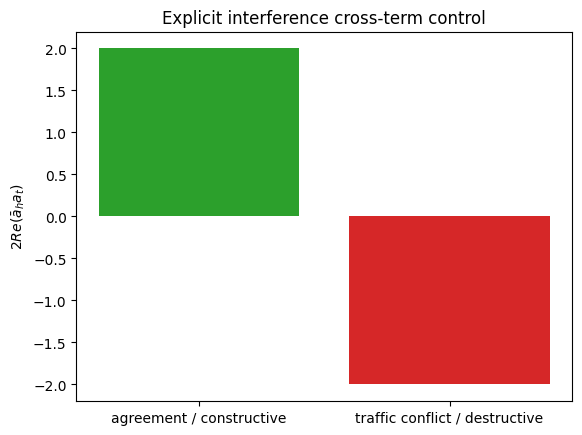

In [34]:
import copy
import math
import time
from dataclasses import dataclass, field
from typing import Callable, Mapping, Sequence

import numpy as np
import matplotlib.pyplot as plt

@dataclass
class QuantumAmplitudeState:
    """Pheromone memory and last traffic relation for all possible VRP transitions."""
    n: int
    initial: float = 1.0
    pheromone: np.ndarray = field(init=False)

    def __post_init__(self) -> None:
        self.pheromone = np.full((self.n, self.n), self.initial)
        np.fill_diagonal(self.pheromone, 0)

class InterferenceEngine:
    """Build/measure historical and traffic amplitudes; retain every cross term."""

    def __init__(self, problem: DynamicVRP, state: QuantumAmplitudeState, cfg: Mapping[str, object]) -> None:
        self.problem, self.state, self.cfg, self.log = problem, state, cfg, []

    def scores(
        self,
        i: int,
        candidates: Sequence[int],
        delta: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Return normalized history score, normalized traffic score, and relation phase.

        Important:
        Phase is based on actual edge congestion and actual worsening,
        not merely on being worse than the best candidate in the candidate list.
        """
        c = np.asarray(candidates, int)

        current = np.maximum(self.problem.weight[i, c], 1e-12)
        base = np.maximum(self.problem.base[i, c], 1e-12)

        # Relative edge-level change.
        change = delta[i, c] / base

        # Static heuristic: shorter base distance is better.
        static_eta = (1.0 / base) ** float(self.cfg['beta'])

        # Historical amplitude: pheromone memory plus static heuristic.
        history_raw = (
            self.state.pheromone[i, c] ** float(self.cfg['alpha'])
        ) * static_eta

        # Traffic amplitude:
        # base/current > 1 when the edge is faster than base,
        # base/current < 1 when the edge is congested.
        traffic_ratio = np.clip(base / current, 0.05, 8.0)

        # Penalize edges that worsened, slightly reward improving edges.
        change_factor = (
            np.exp(
                -float(self.cfg['positive_change_sensitivity'])
                * np.maximum(change, 0.0)
            )
            * np.exp(0.5 * np.minimum(change, 0.0))
        )

        traffic_raw = traffic_ratio * change_factor

        # Normalize so history_weight and traffic_weight are meaningful.
        history = history_raw / (np.max(history_raw) + 1e-12)
        traffic = traffic_raw / (np.max(traffic_raw) + 1e-12)

        # Absolute congestion and absolute worsening.
        # In a static network these are zero.
        congestion = np.maximum(current / base - 1.0, 0.0)
        worsening = np.maximum(change, 0.0)

        congestion_scale = float(self.cfg.get('phase_congestion_scale', 1.0))
        worsening_scale = float(self.cfg.get('phase_worsening_scale', 0.35))

        bad_congestion = np.clip(congestion / congestion_scale, 0.0, 1.0)
        bad_worsening = np.clip(worsening / worsening_scale, 0.0, 1.0)

        # Conflict means history likes an edge that is actually bad now.
        conflict = np.clip(
            history * (0.6 * bad_congestion + 0.4 * bad_worsening),
            0.0,
            1.0
        )

        phase = np.pi * np.clip(
            0.30 * bad_congestion +
            0.25 * bad_worsening +
            0.85 * conflict,
            0.0,
            1.0
        )

        # Do not allow complete destructive collapse by default.
        phase_max_fraction = float(self.cfg.get('phase_max_fraction', 0.85))
        phase = np.minimum(phase, phase_max_fraction * np.pi)

        return history, traffic, phase

    def probabilities(
        self,
        i: int,
        candidates: Sequence[int],
        delta: np.ndarray,
        traffic_weight: float,
        interference_on: bool,
        classical_control: bool,
        iteration: int
    ) -> np.ndarray:
        """
        Filter first, then calculate either amplitude interference or classical fusion probabilities.

        For interference, a small classical baseline is retained so the distribution
        cannot collapse due to overly destructive phases.
        """
        h, t, phase = self.scores(i, candidates, delta)

        wh = float(self.cfg['history_weight'])
        wt = float(traffic_weight)

        if interference_on:
            ah = wh * np.sqrt(np.maximum(h, 0.0)).astype(complex)
            at = wt * np.sqrt(np.maximum(t, 0.0)) * np.exp(1j * phase)

            cross = 2.0 * np.real(np.conj(ah) * at)
            intensity = np.abs(ah + at) ** 2

            # Safety baseline: keep some classical score even when interference is destructive.
            baseline_fraction = float(self.cfg.get('interference_baseline', 0.15))
            baseline = baseline_fraction * (wh * h + wt * t)

            scores = intensity + baseline + 1e-10
        else:
            cross = np.zeros_like(h)

            if classical_control:
                scores = wh * h + wt * t + 1e-10
            else:
                scores = h + 1e-10

        prob = scores / scores.sum()

        for j, x, p, ph in zip(candidates, cross, prob, phase):
            self.log.append({
                'iteration': iteration,
                'i': i,
                'j': int(j),
                'cross_term': float(x),
                'probability': float(p),
                'phase': float(ph)
            })

        return prob

def interference_demo() -> None:
    """Demonstrate fixed constructive and destructive cases with the exact cross term."""
    ah=np.array([1+0j,1+0j]); at=np.array([1+0j,np.exp(1j*np.pi)])
    cross=2*np.real(np.conj(ah)*at)
    assert cross[0] > 0 and cross[1] < 0
    plt.bar(['agreement / constructive','traffic conflict / destructive'],cross,color=['tab:green','tab:red'])
    plt.ylabel(r'$2 Re(\bar a_h a_t)$'); plt.title('Explicit interference cross-term control'); plt.show()
interference_demo()


## 3. Classical multi-route construction, local exploitation, and dynamic pheromones

Construction assigns customers to vehicle routes one at a time. Capacity/time-window feasibility is applied **before** amplitude measurement. Local search is classical exploitation, not a quantum contribution: it applies feasible 2-opt, relocate, swap, and cross-route relocate moves.

In [35]:
def solution_key(s: Solution) -> tuple[tuple[int,...],...]: return tuple(tuple(r) for r in s)
def edge_set(s: Solution) -> set[tuple[int,int]]: return {tuple(sorted((i,j))) for r in s for i,j in zip(r[:-1],r[1:])}
def solution_diversity(pop: Sequence[Solution]) -> float:
    """Mean Jaccard edge distance across a population."""
    if len(pop)<2:return 0.0
    vals=[]
    for a in range(len(pop)):
        for b in range(a):
            x,y=edge_set(pop[a]),edge_set(pop[b]); vals.append(1-len(x&y)/max(1,len(x|y)))
    return float(np.mean(vals))
def entropy(tau: np.ndarray) -> float:
    p=tau/(tau.sum(axis=1,keepdims=True)+1e-12); return float(np.mean(-np.sum(p*np.log(p+1e-12),axis=1)/np.log(len(tau))))

class LocalSearch:
    """Bounded first-improvement feasible VRP local search."""
    def __init__(self, p: DynamicVRP): self.p=p
    def improve(self, s: Solution, budget: int) -> tuple[Solution,int]:
        current=copy.deepcopy(s); failures=0
        for _ in range(budget):
            before=self.p.objective_parts(current)['objective']; best=copy.deepcopy(current); bestv=before
            # 2-opt, relocate, and swap inside every route.
            for rix,r in enumerate(current):
                for a in range(1,len(r)-2):
                    for b in range(a+1,len(r)-1):
                        z=copy.deepcopy(current); z[rix]=r[:a]+list(reversed(r[a:b+1]))+r[b+1:]
                        if self.p.feasible(z) and self.p.objective_parts(z)['objective']<bestv: best,bestv=z,self.p.objective_parts(z)['objective']
                for a in range(1,len(r)-1):
                    for b in range(1,len(r)-1):
                        if a==b: continue
                        z=copy.deepcopy(current); node=z[rix].pop(a); z[rix].insert(b,node)
                        if self.p.feasible(z) and self.p.objective_parts(z)['objective']<bestv: best,bestv=z,self.p.objective_parts(z)['objective']
                for a in range(1,len(r)-1):
                    for b in range(a+1,len(r)-1):
                        z=copy.deepcopy(current); z[rix][a],z[rix][b]=z[rix][b],z[rix][a]
                        if self.p.feasible(z) and self.p.objective_parts(z)['objective']<bestv: best,bestv=z,self.p.objective_parts(z)['objective']
            # Cross-route relocate.
            for x in range(len(current)):
                for y in range(len(current)):
                    if x==y: continue
                    for a in range(1,len(current[x])-1):
                        z=copy.deepcopy(current); node=z[x].pop(a); z[y].insert(-1,node); z=[r for r in z if len(r)>2]
                        if self.p.feasible(z) and self.p.objective_parts(z)['objective']<bestv: best,bestv=z,self.p.objective_parts(z)['objective']
            if bestv >= before-1e-12: failures += 1; break
            current=best
        return current, failures

def adaptive_evaporate(state: QuantumAmplitudeState, population: Sequence[Solution], problem: DynamicVRP, rho: float, deposit: float) -> None:
    """Classical pheromone learning; its dynamic evaporation is distinct from amplitude interference."""
    state.pheromone *= (1-rho)
    for s in population:
        q=deposit/max(problem.objective_parts(s)['objective'],1e-9)
        for r in s:
            for i,j in zip(r[:-1],r[1:]): state.pheromone[i,j]+=q; state.pheromone[j,i]+=q
    state.pheromone=np.maximum(state.pheromone,1e-9)

## 4. Tunneling-inspired nonlocal transitions and adaptive barrier acceptance

The operator tries large segment reversal, segment relocation, cross-route block relocation, route exchange, or a traffic-shock repair. It preserves feasibility. Unlike V1, a feasible candidate beyond a modest fitness barrier may be accepted with `exp(-ΔF/T_tunnel)`; temperature falls through the run but rises with stagnation/volatility. This is an analogy for exploration, not literal physical tunneling.

In [36]:
class TunnelingOperator:
    """Feasibility-preserving nonlocal VRP basin-transition operator."""

    def __init__(self, p: DynamicVRP, rng: np.random.Generator):
        self.p = p
        self.rng = rng

    def propose(self, s: Solution, affected: list[int] | None = None) -> Solution:
        original = copy.deepcopy(s)
        base_obj = self.p.objective_parts(original)['objective']
        feasible_candidates: list[tuple[float, Solution]] = []

        for _ in range(25):
            z = copy.deepcopy(original)

            nonempty = [k for k, r in enumerate(z) if len(r) > 3]
            if affected:
                target = list(set(nonempty) & set(affected)) or nonempty
            else:
                target = nonempty

            if not target:
                return original

            op = int(self.rng.integers(4))

            if op == 0:
                # Large segment reversal.
                k = int(self.rng.choice(target))
                r = z[k]
                if len(r) > 4:
                    a = int(self.rng.integers(1, max(2, len(r) - 2)))
                    b = int(self.rng.integers(a + 1, len(r) - 1))
                    z[k] = r[:a] + r[a:b + 1][::-1] + r[b + 1:]

            elif op == 1:
                # Large segment relocation inside the same route.
                k = int(self.rng.choice(target))
                r = z[k]
                if len(r) > 5:
                    a = int(self.rng.integers(1, len(r) - 3))
                    b = min(len(r) - 1, a + int(self.rng.integers(1, 3)))
                    block = r[a:b]
                    del z[k][a:b]
                    pos = int(self.rng.integers(1, max(2, len(z[k]) - 1)))
                    z[k][pos:pos] = block

            elif op == 2 and len(z) > 1:
                # Cross-route node relocation with capacity check.
                x = int(self.rng.choice(target))
                others = [k for k in range(len(z)) if k != x]
                if others and len(z[x]) > 3:
                    y = int(self.rng.choice(others))
                    pos = int(self.rng.integers(1, len(z[x]) - 1))
                    node = z[x].pop(pos)

                    load_y = sum(self.p.demand[c] for c in z[y][1:-1]) + self.p.demand[node]
                    if load_y <= float(self.p.cfg['capacity']) + 1e-9:
                        z[y].insert(len(z[y]) - 1, node)
                    else:
                        z[x].insert(pos, node)

            else:
                # Swap customers between two routes.
                if len(z) > 1:
                    x, y = self.rng.choice(len(z), 2, replace=False)
                    x, y = int(x), int(y)
                    if len(z[x]) > 3 and len(z[y]) > 3:
                        px = int(self.rng.integers(1, len(z[x]) - 1))
                        py = int(self.rng.integers(1, len(z[y]) - 1))
                        z[x][px], z[y][py] = z[y][py], z[x][px]

            if self.p.feasible(z) and solution_key(z) != solution_key(original):
                obj = self.p.objective_parts(z)['objective']
                feasible_candidates.append((obj, z))

                # If we already found an improving nonlocal move, return it immediately.
                if obj < base_obj:
                    return z

        if feasible_candidates:
            feasible_candidates.sort(key=lambda item: item[0])
            return feasible_candidates[0][1]

        return original

    def tunnel_accept(self, current: float, new: float, iteration: int, total: int, stagnation: int,volatility: float,cfg: Mapping[str, object],rng: np.random.Generator) -> bool:
        """Accept improvements; otherwise cross only bounded relative barriers."""
        if new <= current:
            return True

        delta = (new - current) / max(abs(current), 1e-12)
        barrier_max = float(cfg.get('tunnel_barrier_max', 0.18))

        # Do not allow crossing huge barriers.
        if delta > barrier_max:
            return False

        temp = (float(cfg['tunnel_temperature'])* (0.30 + 0.70 * (1.0 - iteration / max(total, 1)))* (1.0 + min(stagnation / float(cfg['S_max']), 2.0) + 4.0 * volatility))

        exponent = min(delta / max(temp, 1e-12), 40.0)
        return bool(rng.random() < math.exp(-exponent))

@dataclass
class AdaptiveController:
    """Maps observed search state into bounded exploration/exploitation controls."""
    cfg: Mapping[str, object]

    def controls(
        self,
        stagnation: int,
        diversity: float,
        volatility: float,
        ls_fail: int,
        adaptive: bool
    ) -> dict[str, float]:
        stag = stagnation / max(float(self.cfg['S_max']), 1.0)

        if adaptive:
            pressure = np.clip(
                0.45 * stag +
                0.25 * (1.0 - diversity) +
                3.0 * volatility +
                0.12 * ls_fail,
                0.0,
                1.0
            )
        else:
            # Even without full adaptation, tunneling should respond to stagnation.
            pressure = np.clip(stag, 0.0, 1.0)

        traffic_weight = float(self.cfg['traffic_weight'])
        candidate_k = int(self.cfg['candidate_k'])
        rho = float(self.cfg['rho'])
        ls_budget = int(self.cfg['local_search_moves'])

        if adaptive:
            traffic_weight = float(np.clip(
                traffic_weight * (1.0 + 1.4 * pressure),
                0.25,
                1.75
            ))

            candidate_k = int(np.clip(
                int(self.cfg['candidate_k']) + round(4.0 * pressure),
                int(self.cfg['candidate_k_min']),
                int(self.cfg['candidate_k_max'])
            ))

            rho = float(np.clip(
                rho + 0.22 * pressure,
                float(self.cfg['rho_min']),
                float(self.cfg['rho_max'])
            ))

            ls_budget = int(np.clip(
                int(self.cfg['local_search_moves']) + round(4.0 * (1.0 - pressure)),
                1,
                8
            ))

        tunnel_p = float(np.clip(0.12 + 0.60 * pressure, 0.12, 0.80))

        return {
            'traffic_weight': traffic_weight,
            'candidate_k': candidate_k,
            'rho': rho,
            'ls_budget': ls_budget,
            'tunnel_p': tunnel_p,
        }

## 5. Unified dynamic VRP ACO runner and partial reconstruction

The common runner lets every ablation flip only flags. On a shock, it identifies routes containing changed edges, freezes the other routes, removes affected customers, and reconstructs only the affected routes with the same traffic-aware decision engine. Metrics record the scope and runtime of this localized response.

In [37]:
class DynamicQACO:
    """Unified, reproducible ACO/QACO dynamic-VRP engine."""
    def __init__(self,cfg:Mapping[str,object],flags:Mapping[str,bool]):
        self.cfg={**cfg}; self.flags={**FLAGS,**flags}; self.p=DynamicVRP(self.cfg); self.rng=np.random.default_rng(int(self.cfg['seed']))
        self.state=QuantumAmplitudeState(len(self.p.demand)); self.interference=InterferenceEngine(self.p,self.state,self.cfg); self.local=LocalSearch(self.p); self.tunneler=TunnelingOperator(self.p,self.rng); self.controller=AdaptiveController(self.cfg)
    def _build(self,delta:np.ndarray, controls:Mapping[str,float], customers:Sequence[int]|None=None, fixed:Solution|None=None)->Solution:
        """Construct feasible multi-route VRP solution, applying candidate filtering before sampling."""
        remaining=set(range(1,len(self.p.demand))) if customers is None else set(customers); routes=copy.deepcopy(fixed) if fixed else []
        used_load=[sum(self.p.demand[c] for c in r[1:-1]) for r in routes]
        while remaining and len(routes)<int(self.cfg['n_vehicles']):
            route=[0]; load=0.; clock=0.
            while remaining:
                feasible=[j for j in remaining if load+self.p.demand[j]<=float(self.cfg['capacity']) and clock+self.p.weight[route[-1],j]<=self.p.tw_close[j]]
                if not feasible:break
                i=route[-1]; feasible=sorted(feasible,key=lambda j:self.p.weight[i,j])[:int(controls['candidate_k'])]
                prob=self.interference.probabilities(i,feasible,delta,controls['traffic_weight'],self.flags['interference_on'],self.flags['classical_fusion_control'],self.iteration)
                j=int(self.rng.choice(feasible,p=prob)); route.append(j); remaining.remove(j); load+=self.p.demand[j]; clock+=self.p.weight[i,j]
            route.append(0)
            if len(route)>2:routes.append(route)
            else:break
        # Deterministic repair: insert any leftover customer at best feasible position.
        for j in list(remaining):
            placed=False
            for r in routes:
                for pos in range(1,len(r)):
                    z=copy.deepcopy(routes); z[routes.index(r)].insert(pos,j)
                    if self.p.feasible(z): routes=z; placed=True; break
                if placed:break
            if not placed and len(routes)<int(self.cfg['n_vehicles']) and self.p.demand[j]<=float(self.cfg['capacity']): routes.append([0,j,0]); placed=True
            if placed: remaining.remove(j)
        return routes
    def partial_reconstruct(self,s:Solution,delta:np.ndarray,controls:Mapping[str,float])->tuple[Solution,int,int]:
        """Freeze unaffected routes; reconstruct customer portions from shock-affected routes only."""
        affected=self.p.affected_route_indices(s)
        if not affected:return s,0,0
        frozen=[r for k,r in enumerate(s) if k not in affected]; pool=[c for k in affected for c in s[k][1:-1]]
        started=time.perf_counter(); rebuilt=self._build(delta,controls,pool,frozen); elapsed=int((time.perf_counter()-started)*1000)
        return rebuilt,len(affected),elapsed
    def run(self) -> tuple[list[dict[str, float]], list[dict[str, float]]]:
        records = []
        unique = set()

        best = None
        bestv = float('inf')
        current = None

        stagnation = 0
        ls_fail = 0

        tunnel_proposals = 0
        tunnel_feasible = 0
        tunnel_accepted = 0
        tunnel_improved = 0

        last_diversity = 0.0
        last_reconstruct = -999

        start = time.perf_counter()

        for self.iteration in range(int(self.cfg['iterations'])):
            # Preferentially shock edges used by current incumbent so dynamic effect is visible.
            prefer_edges = edge_set(current) if current is not None else None
            vol, delta = self.p.advance(
            self.iteration,
            bool(self.flags['dynamic_on']),
            prefer_edges)

                        # Validation helper: if a shock iteration occurs but the incumbent
            # is not affected, force some shocked edges to belong to the incumbent.
            if (
                bool(self.flags['dynamic_on'])
                and self.iteration in self.p.cfg['shock_iterations']
                and current is not None
            ):
                if len(self.p.affected_route_indices(current)) == 0:
                    current_edges = list(edge_set(current))

                    if len(current_edges) >= 2:
                        rng_shock = np.random.default_rng(
                            int(self.cfg['seed']) + self.iteration + 777
                        )

                        m = max(
                            2,
                            int(len(current_edges) * float(self.cfg.get('shock_edge_fraction', 0.25)))
                        )

                        chosen_idx = rng_shock.choice(
                            len(current_edges),
                            size=min(m, len(current_edges)),
                            replace=False
                        )

                        chosen_edges = [
                            tuple(sorted(current_edges[int(k)]))
                            for k in chosen_idx
                        ]

                        duration = int(self.cfg.get('shock_duration', 30))

                        for e in chosen_edges:
                            self.p.active_shocks[e] = self.iteration + duration

                        self.p.changed_edges = set(self.p.active_shocks.keys())

                        # Apply shock to weights immediately.
                        shock = np.zeros_like(self.p.base)
                        for ii, jj in self.p.changed_edges:
                            shock[ii, jj] = shock[jj, ii] = float(self.cfg['shock_strength'])

                        factor = self.p.weight / np.maximum(self.p.base, 1e-12)

                        self.p.previous = self.p.weight.copy()
                        self.p.weight = self.p.base * np.maximum(0.05, factor + shock)
                        np.fill_diagonal(self.p.weight, 0.0)

                        delta = self.p.weight - self.p.previous
                        vol = float(
                            np.linalg.norm(delta)
                            / (np.linalg.norm(self.p.previous) + 1e-12)
                        )

            ctl = self.controller.controls(stagnation,last_diversity,vol,ls_fail,bool(self.flags['adaptive_on']))

            pop = [self._build(delta, ctl)for _ in range(int(self.cfg['num_ants']))]

            raw_vals = [self.p.objective_parts(s)['objective'] for s in pop]
            pre_local_best = float(min(raw_vals)) if raw_vals else float('inf')

            if self.flags['local_search_on']:
                # Improve only the best quarter of the population.
                # This prevents deterministic local search from erasing all construction diversity.
                idxs = np.argsort(raw_vals)[:max(1, len(pop) // 4)]
                failures = []

                for ix in idxs:
                    pop[int(ix)], f = self.local.improve(pop[int(ix)], int(ctl['ls_budget']))
                    failures.append(f)

                ls_fail = int(np.mean(failures)) if failures else 0

            vals = [self.p.objective_parts(s)['objective'] for s in pop]
            candidate = pop[int(np.argmin(vals))]
            cv = min(vals)

            if current is None or cv < self.p.objective_parts(current)['objective']:
                current = copy.deepcopy(candidate)

            affected_idx = self.p.affected_route_indices(current) if current is not None else []
            affected = len(affected_idx)
            rebuild_ms = 0

            if bool(self.flags.get('partial_reconstruct_on', False)) and affected_idx:
                cooldown = int(self.cfg.get('reconstruct_cooldown', 3))
                should_rebuild = (vol > float(self.cfg['volatility_reconstruct_threshold'])or (self.iteration - last_reconstruct) >= cooldown)

                if should_rebuild:
                    current, affected_count, rebuild_ms = self.partial_reconstruct(current, delta, ctl)
                    affected = affected_count
                    last_reconstruct = self.iteration

                    if self.flags['local_search_on']:
                        current, _ = self.local.improve(current, max(1, int(ctl['ls_budget'])))

            want_tunnel = (self.flags['tunneling_on']and current is not None and (stagnation >= int(self.cfg['S_max'])or (affected > 0 and stagnation >= max(1, int(self.cfg['S_max']) // 3))))

            if want_tunnel and self.rng.random() < float(ctl['tunnel_p']):
                tunnel_proposals += 1

                proposal = self.tunneler.propose(current,self.p.affected_route_indices(current))

                old = self.p.objective_parts(current)['objective']
                new = self.p.objective_parts(proposal)['objective']

                if solution_key(proposal) != solution_key(current):
                    tunnel_feasible += 1

                    if self.tunneler.tunnel_accept(old,new,self.iteration,int(self.cfg['iterations']),stagnation,vol,self.cfg,self.rng):
                        current = proposal
                        tunnel_accepted += 1

                        if new < old:
                            tunnel_improved += 1

            value = self.p.objective_parts(current)['objective']

            if value < bestv - 1e-9:
                best = copy.deepcopy(current)
                bestv = value
                stagnation = 0
            else:
                stagnation += 1

            adaptive_evaporate(self.state,pop,self.p,float(ctl['rho']),float(self.cfg['deposit']))

            unique.update(solution_key(s) for s in pop)

            pop_diversity = solution_diversity(pop)
            last_diversity = pop_diversity

            parts = self.p.objective_parts(current)

            records.append({
                **parts,
                'iteration': self.iteration,
                'runtime_s': time.perf_counter() - start,
                'pre_local_best': pre_local_best,
                'volatility': vol,
                'diversity': pop_diversity,
                'edge_diversity': len(set().union(*[edge_set(x) for x in pop])) if pop else 0,
                'entropy': entropy(self.state.pheromone),
                'unique_solutions': len(unique),
                'stagnation': stagnation,
                'traffic_weight': float(ctl['traffic_weight']),
                'tunnel_p': float(ctl['tunnel_p']),
                'tunneling_events': tunnel_proposals,
                'tunnel_feasible': tunnel_feasible,
                'successful_tunnels': tunnel_accepted,
                'improving_tunnels': tunnel_improved,
                'affected_routes': affected,
                'reconstructed_customers': sum(
                    len(current[k]) - 2
                    for k in self.p.affected_route_indices(current)
                ) if affected else 0,
                'reconstruction_ms': rebuild_ms,
            })

        return records, self.interference.log

## 6. Rigorous ablations, classical interference control, and frozen empirical reference

The eight requested variants use identical budgets and repeated seeds. `Classical traffic fusion control` has the same historical/traffic scores but combines them as a weighted scalar sum. Its comparison with interference isolates whether the cross term changes behavior. The separate high-budget reference is computed before variant evaluation and is labeled empirical.

In [38]:
STATIC_VARIANTS = {
    'V1 Classical ACO': {},
    'V2 ACO + Local Search': {
        'local_search_on': True
    },
    'V3 ACO + Interference': {
        'interference_on': True
    },
    'V4 ACO + Tunneling': {
        'tunneling_on': True
    },
    'V5 Interference + Tunneling': {
        'interference_on': True,
        'tunneling_on': True,
        'adaptive_on': True
    },
    'V6 Full QACO weak LS': {
        'interference_on': True,
        'tunneling_on': True,
        'local_search_on': True,
        'adaptive_on': True
    },
    'V7 Classical fusion control': {
        'classical_fusion_control': True,
        'adaptive_on': True
    },
    'V8 Classical fusion + LS': {
        'classical_fusion_control': True,
        'adaptive_on': True,
        'local_search_on': True
    },
}

DYNAMIC_VARIANTS = {}

for name, flags in STATIC_VARIANTS.items():
    dynamic_name = name.replace('V', 'DV')
    DYNAMIC_VARIANTS[dynamic_name] = {
        **flags,
        'dynamic_on': True,
        'partial_reconstruct_on': False,
    }

DYNAMIC_VARIANTS['DV9 Dynamic Full QACO'] = {
    'interference_on': True,
    'tunneling_on': True,
    'local_search_on': True,
    'adaptive_on': True,
    'dynamic_on': True,
    'partial_reconstruct_on': True,
}
def run_experiments(
    variants: dict[str, dict[str, bool]],
    seeds: Sequence[int] = (17, 23)
) -> dict[str, list[list[dict[str, float]]]]:
    results = {name: [] for name in variants}

    for seed in seeds:
        for name, flags in variants.items():
            engine = DynamicQACO({**CFG, 'seed': seed}, flags)
            records, _ = engine.run()
            results[name].append(records)

    return results

# Freeze an independent, high-budget empirical reference before comparisons (not a BKS/public optimum).
# ------------------------------------------------------------------
# Frozen empirical references
# ------------------------------------------------------------------
# These are not public BKS values. They are only internal reference
# values for convergence diagnostics.
# ------------------------------------------------------------------

REFERENCE_CFG = {
    **CFG,
    'iterations': 220,
    'num_ants': 18,
    'seed': 101
}

reference_flags_static = {
    'interference_on': True,
    'tunneling_on': True,
    'local_search_on': True,
    'adaptive_on': True,
    'dynamic_on': False,
    'partial_reconstruct_on': False,
}

reference_records_static, _ = DynamicQACO(
    REFERENCE_CFG,
    reference_flags_static
).run()

EMPIRICAL_REFERENCE_STATIC = float(
    min(
        r.get('pre_local_best', r['objective'])
        for r in reference_records_static
    )
)

print(f'Static empirical reference objective: {EMPIRICAL_REFERENCE_STATIC:.4f}')


reference_flags_dynamic = {
    'interference_on': True,
    'tunneling_on': True,
    'local_search_on': True,
    'adaptive_on': True,
    'dynamic_on': True,
    'partial_reconstruct_on': True,
}

REFERENCE_CFG_DYNAMIC = {
    **REFERENCE_CFG,
    'seed': 102
}

reference_records_dynamic, _ = DynamicQACO(
    REFERENCE_CFG_DYNAMIC,
    reference_flags_dynamic
).run()

EMPIRICAL_REFERENCE_DYNAMIC = float(
    min(
        r.get('pre_local_best', r['objective'])
        for r in reference_records_dynamic
    )
)

print(f'Dynamic empirical reference objective: {EMPIRICAL_REFERENCE_DYNAMIC:.4f}')
# ------------------------------------------------------------------
# Main experiments
# ------------------------------------------------------------------

static_results = run_experiments(
    STATIC_VARIANTS,
    seeds=(17, 23)
)

dynamic_results = run_experiments(
    DYNAMIC_VARIANTS,
    seeds=(17, 23)
)


Static empirical reference objective: 7.1335
Dynamic empirical reference objective: 7.4893


In [39]:
# ------------------------------------------------------------------
# Diagnostic experiment: mechanism behavior without local search
# ------------------------------------------------------------------
# Use this first to verify that interference and tunneling are active.
# If these variants all behave identically, the problem is still too
# easy or the mechanisms are too weak.
# ------------------------------------------------------------------

MECHANISM_DIAGNOSTIC = {
    'M1 Classical': {},
    'M2 Interference': {
        'interference_on': True
    },
    'M3 Tunneling': {
        'tunneling_on': True
    },
    'M4 Interference + Tunneling': {
        'interference_on': True,
        'tunneling_on': True,
        'adaptive_on': True
    },
    'M5 Classical fusion': {
        'classical_fusion_control': True,
        'adaptive_on': True
    },
}

mechanism_results = run_experiments(
    MECHANISM_DIAGNOSTIC,
    seeds=(17,)
)

## 7. Metrics, dynamic recovery, and presentation-ready visualizations

The plots cover road geometry, traffic shocks, convergence, diversity, pheromone state, phases/cross terms, tunneling, affected routes, and recovery. Dynamic recovery is measured against the pre-shock incumbent under the new traffic, rather than using a circular minimum from the variants as a BKS.

Dynamic shock debug for DV9 Dynamic Full QACO
  shock 40: volatility_max=0.902, affected_max=0, reconstructed_max=0, rebuild_ms_max=0
  shock 85: volatility_max=0.886, affected_max=1, reconstructed_max=5, rebuild_ms_max=1
  shock 130: volatility_max=0.920, affected_max=0, reconstructed_max=0, rebuild_ms_max=0

STATIC EXPERIMENT SUMMARY
{'variant': 'V1 Classical ACO', 'objective_mean': 6.98166652006983, 'objective_std': 0.2440263986327751, 'pre_local_mean': 7.5964853218253, 'pre_local_std': 0.2898883556755405, 'distance': 5.305333216055864, 'travel_time': 5.305333216055864, 'congestion': 0.0, 'vehicles': 3.5, 'violations': 0.0, 'unique': 1246.5, 'diversity': 0.4349226066820655, 'edge_diversity': 52.0, 'entropy': 0.45700419491421385, 'tunnel_proposals': 0.0, 'tunnel_feasible': 0.0, 'tunnel_success': 0.0, 'tunnel_improving': 0.0, 'affected_routes_final_mean': 0.0, 'affected_routes_all_mean': 0.0, 'affected_routes_max_mean': 0.0, 'reconstruction_events_mean': 0.0, 'reconstructed_customers_

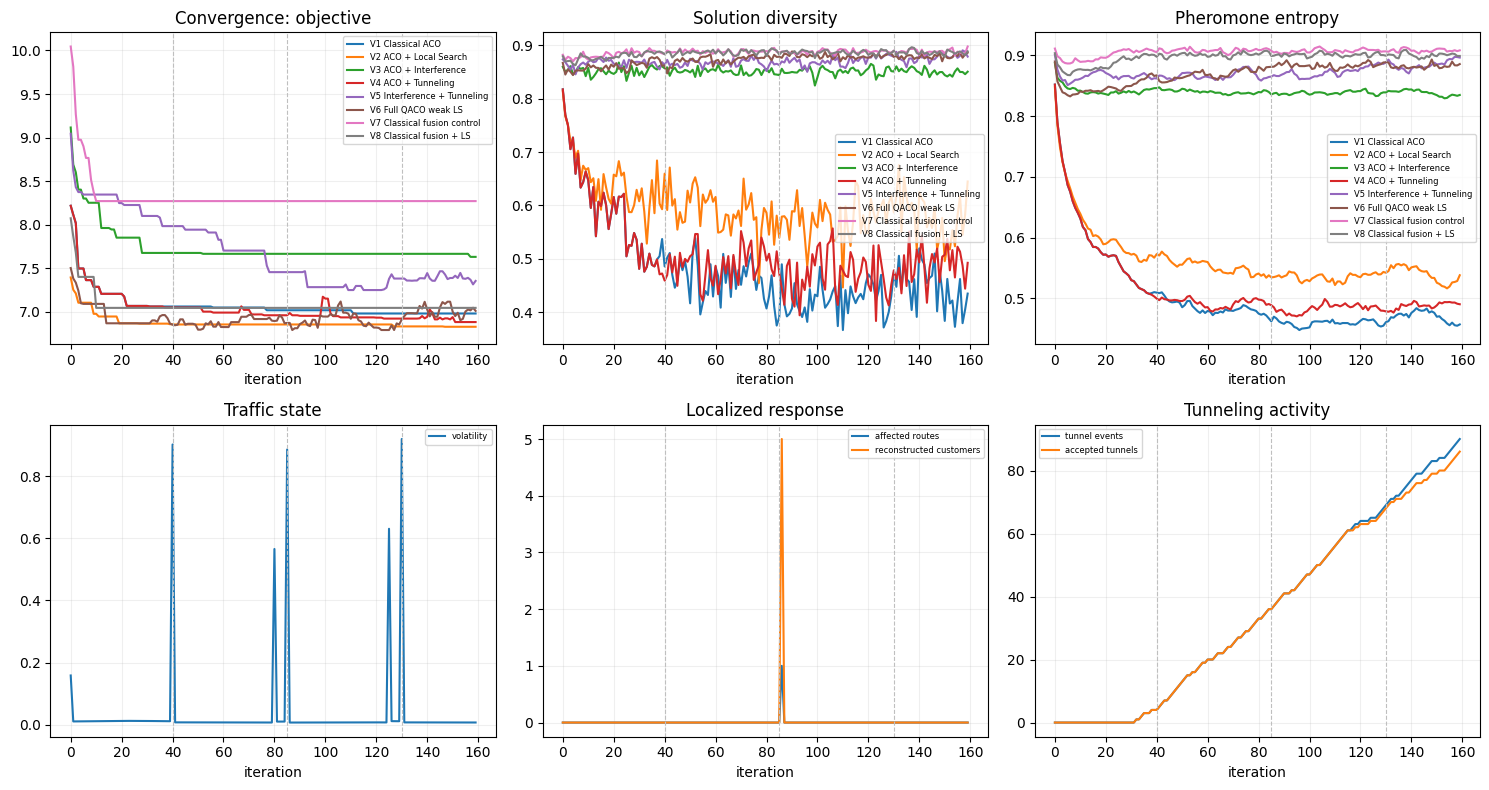

Interference audit:
  number of logged decisions: 60529
  mean phase:                 0.1051
  positive cross terms:       59987
  negative cross terms:       542
  mean cross term:            0.423921


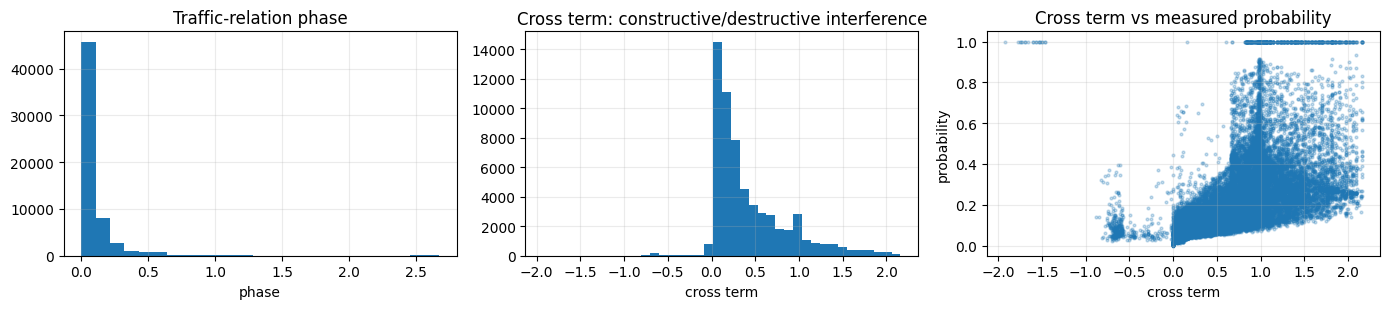

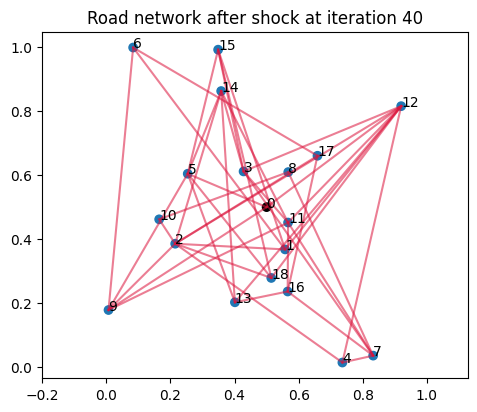

In [40]:
def mean_series(runs:Sequence[Sequence[Mapping[str,float]]],key:str)->np.ndarray:return np.mean([[r[key] for r in run] for run in runs],axis=0)
def recovery_after_shock(
    records: Sequence[Mapping[str, float]],
    shock: int,
    key: str = 'objective'
) -> float:
    """
    Iterations until the selected metric returns to the pre-shock median.
    Returns NaN if recovery does not occur.
    """
    if shock < 0 or shock >= len(records):
        return float('nan')

    pre = records[max(0, shock - 8):shock]

    if len(pre) == 0:
        return float('nan')

    target = float(np.median([r[key] for r in pre]))

    return next(
        (
            r['iteration'] - shock
            for r in records[shock:]
            if r[key] <= target
        ),
        float('nan')
    )
def report(
    results: Mapping[str, Sequence[Sequence[Mapping[str, float]]]],
    reference_value: float
) -> list[dict[str, float | str]]:
    """
    Aggregate quality, exploration, tunneling, dynamic response, and convergence metrics.

    Important:
    - Objective and final-state metrics are taken from the final record.
    - Dynamic response metrics are aggregated over the whole run.
    """
    out = []

    reference_value = float(reference_value)
    target = reference_value * 1.05

    for name, runs in results.items():
        if len(runs) == 0:
            continue

        final = [run[-1] for run in runs if len(run) > 0]
        all_records = [x for run in runs for x in run]

        hits = []
        for run in runs:
            hit = next(
                (
                    x['iteration']
                    for x in run
                    if x.get('pre_local_best', x['objective']) <= target
                ),
                np.nan
            )
            hits.append(hit)

        hits = np.asarray(hits, dtype=float)

        if hits.size > 0 and np.any(~np.isnan(hits)):
            iterations_to_target = float(np.nanmean(hits))
        else:
            iterations_to_target = float('nan')

        out.append({
            'variant': name,

            # Final objective metrics
            'objective_mean': float(np.mean([x['objective'] for x in final])),
            'objective_std': float(np.std([x['objective'] for x in final])),

            # Construction-phase metrics
            'pre_local_mean': float(np.mean([x.get('pre_local_best', x['objective']) for x in final])),
            'pre_local_std': float(np.std([x.get('pre_local_best', x['objective']) for x in final])),

            # Final route properties
            'distance': float(np.mean([x['distance'] for x in final])),
            'travel_time': float(np.mean([x['travel_time'] for x in final])),
            'congestion': float(np.mean([x['congestion'] for x in final])),
            'vehicles': float(np.mean([x['vehicles'] for x in final])),
            'violations': float(np.mean([x['violations'] for x in final])),

            # Final exploration metrics
            'unique': float(np.mean([x['unique_solutions'] for x in final])),
            'diversity': float(np.mean([x['diversity'] for x in final])),
            'edge_diversity': float(np.mean([x.get('edge_diversity', 0.0) for x in final])),
            'entropy': float(np.mean([x['entropy'] for x in final])),

            # Tunneling metrics are cumulative in the final record
            'tunnel_proposals': float(np.mean([x.get('tunneling_events', 0.0) for x in final])),
            'tunnel_feasible': float(np.mean([x.get('tunnel_feasible', 0.0) for x in final])),
            'tunnel_success': float(np.mean([x.get('successful_tunnels', 0.0) for x in final])),
            'tunnel_improving': float(np.mean([x.get('improving_tunnels', 0.0) for x in final])),

            # Dynamic response metrics over entire run
            'affected_routes_final_mean': float(np.mean([x.get('affected_routes', 0.0) for x in final])),
            'affected_routes_all_mean': float(np.mean([x.get('affected_routes', 0.0) for x in all_records])),
            'affected_routes_max_mean': float(np.mean([
                max((r.get('affected_routes', 0.0) for r in run), default=0.0)
                for run in runs
            ])),

            'reconstruction_events_mean': float(np.mean([
                sum(1 for r in run if r.get('reconstruction_ms', 0.0) > 0)
                for run in runs
            ])),

            'reconstructed_customers_all_mean': float(np.mean([
                x.get('reconstructed_customers', 0.0)
                for x in all_records
            ])),

            'reconstruction_ms_sum_mean': float(np.mean([
                sum(r.get('reconstruction_ms', 0.0) for r in run)
                for run in runs
            ])),

            # Convergence metric
            'iterations_to_empirical_target': iterations_to_target,
        })

    return out
static_summary = report(
    static_results,
    EMPIRICAL_REFERENCE_STATIC
)

dynamic_summary = report(
    dynamic_results,
    EMPIRICAL_REFERENCE_DYNAMIC
)

def dynamic_shock_debug(
    results: Mapping[str, Sequence[Sequence[Mapping[str, float]]]],
    variant_key: str
) -> None:
    if variant_key not in results:
        print(f'{variant_key} not found in results.')
        return

    run = results[variant_key][0]

    print(f'Dynamic shock debug for {variant_key}')

    for shock in CFG['shock_iterations']:
        if shock >= len(run):
            print(f'  shock {shock}: outside run length')
            continue

        end = min(len(run), shock + 15)
        window = run[shock:end]

        affected_max = max(r.get('affected_routes', 0.0) for r in window)
        reconstructed_max = max(r.get('reconstructed_customers', 0.0) for r in window)
        rebuild_ms_max = max(r.get('reconstruction_ms', 0.0) for r in window)
        volatility_max = max(r.get('volatility', 0.0) for r in window)

        print(
            f'  shock {shock}: '
            f'volatility_max={volatility_max:.3f}, '
            f'affected_max={affected_max:.0f}, '
            f'reconstructed_max={reconstructed_max:.0f}, '
            f'rebuild_ms_max={rebuild_ms_max:.0f}'
        )

dynamic_shock_debug(dynamic_results, 'DV9 Dynamic Full QACO')

mechanism_summary = report(
    mechanism_results,
    EMPIRICAL_REFERENCE_STATIC
)

print('\nSTATIC EXPERIMENT SUMMARY')
for row in static_summary:
    print(row)

print('\nDYNAMIC EXPERIMENT SUMMARY')
for row in dynamic_summary:
    print(row)

print('\nMECHANISM DIAGNOSTIC SUMMARY')
for row in mechanism_summary:
    print(row)


fig,ax=plt.subplots(2,3,figsize=(15,8));
for name,runs in static_results.items():
    if name.startswith('V') or name=='Classical traffic fusion control':
        x=np.arange(len(runs[0])); ax[0,0].plot(x,mean_series(runs,'objective'),label=name); ax[0,1].plot(x,mean_series(runs,'diversity'),label=name); ax[0,2].plot(x,mean_series(runs,'entropy'),label=name)
dynamic=dynamic_results['DV9 Dynamic Full QACO'][0]
ax[1,0].plot([r['volatility'] for r in dynamic],label='volatility'); ax[1,1].plot([r['affected_routes'] for r in dynamic],label='affected routes'); ax[1,1].plot([r['reconstructed_customers'] for r in dynamic],label='reconstructed customers'); ax[1,2].plot([r['tunneling_events'] for r in dynamic],label='tunnel events'); ax[1,2].plot([r['successful_tunnels'] for r in dynamic],label='accepted tunnels')
for a,title in zip(ax.flat,['Convergence: objective','Solution diversity','Pheromone entropy','Traffic state','Localized response','Tunneling activity']):
    for shock in CFG['shock_iterations']: a.axvline(shock,color='0.75',ls='--',lw=.8)
    a.set_title(title); a.set_xlabel('iteration'); a.grid(alpha=.2); a.legend(fontsize=6)
plt.tight_layout();plt.show()

# Interference audit: phases, constructive/destructive cross terms, and measured probabilities.
audit_runner = DynamicQACO(
    {
        **CFG,
        'iterations': 50,
        'num_ants': 10,
        'seed': 17
    },
    {
        'interference_on': True,
        'dynamic_on': True,
        'adaptive_on': True
    }
)

_, audit = audit_runner.run()

assert len(audit) > 0, 'Interference audit log is empty.'

cross = np.array([x['cross_term'] for x in audit])
phase = np.array([x['phase'] for x in audit])
prob = np.array([x['probability'] for x in audit])

print('Interference audit:')
print(f'  number of logged decisions: {len(audit)}')
print(f'  mean phase:                 {np.mean(phase):.4f}')
print(f'  positive cross terms:       {np.sum(cross > 0)}')
print(f'  negative cross terms:       {np.sum(cross < 0)}')
print(f'  mean cross term:            {np.mean(cross):.6f}')

fig, ax = plt.subplots(1, 3, figsize=(14, 3.2))

ax[0].hist(phase, bins=25)
ax[0].set_title('Traffic-relation phase')
ax[0].set_xlabel('phase')
ax[0].grid(alpha=0.25)

ax[1].hist(cross, bins=40)
ax[1].set_title('Cross term: constructive/destructive interference')
ax[1].set_xlabel('cross term')
ax[1].grid(alpha=0.25)

ax[2].scatter(cross, prob, s=4, alpha=0.25)
ax[2].set_title('Cross term vs measured probability')
ax[2].set_xlabel('cross term')
ax[2].set_ylabel('probability')
ax[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()
problem = DynamicVRP(CFG)

shock_iter = int(CFG['shock_iterations'][0])

problem.advance(shock_iter, dynamic=True)

plt.figure(figsize=(5.5, 4.5))

plt.scatter(
    problem.coords[:, 0],
    problem.coords[:, 1],
    c=['black'] + ['tab:blue'] * (len(problem.coords) - 1)
)

for i, (x, y) in enumerate(problem.coords):
    plt.text(x, y, str(i))

for i, j in problem.changed_edges:
    plt.plot(
        problem.coords[[i, j], 0],
        problem.coords[[i, j], 1],
        color='crimson',
        alpha=0.55
    )

plt.title(f'Road network after shock at iteration {shock_iter}')
plt.axis('equal')
plt.show()

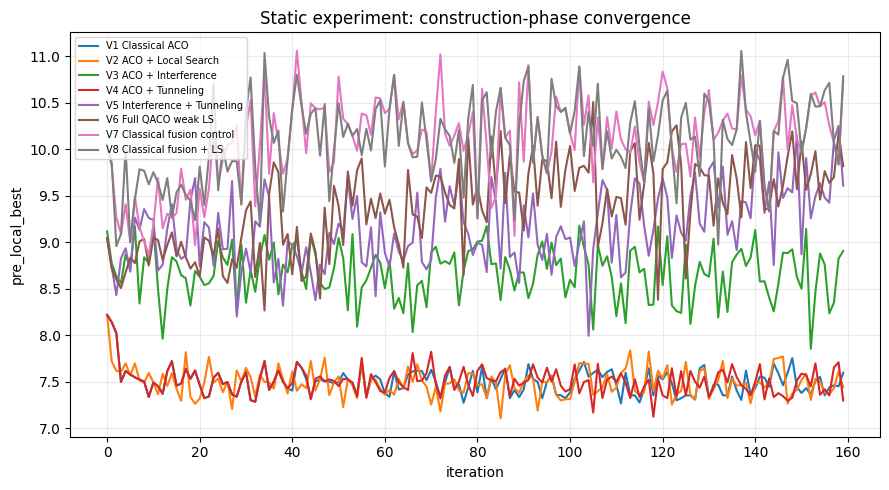

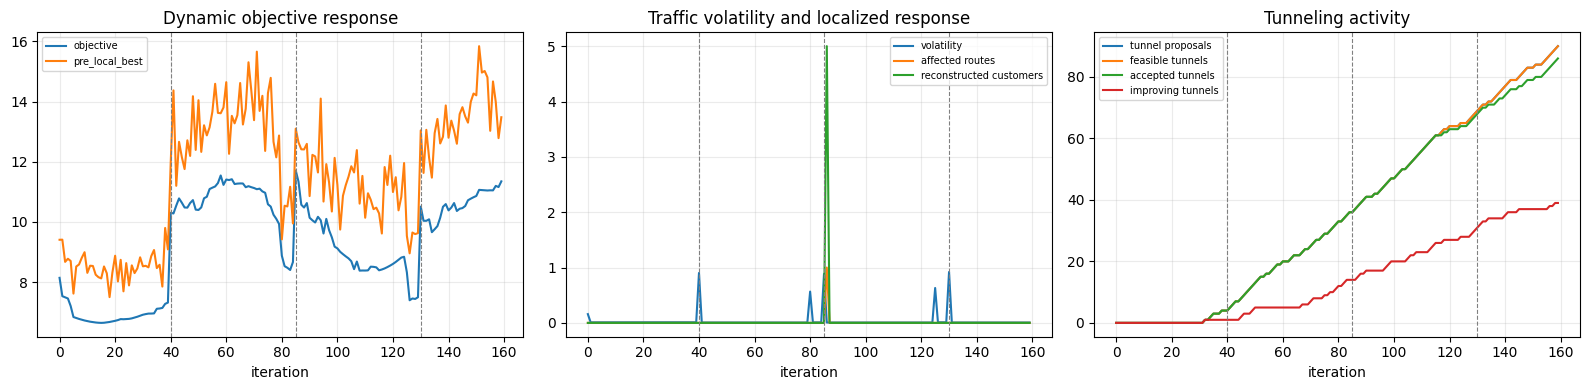

In [41]:
plt.figure(figsize=(9, 5))

for name, runs in static_results.items():
    if len(runs) == 0:
        continue

    x = np.arange(len(runs[0]))
    y = mean_series(runs, 'pre_local_best')

    plt.plot(x, y, label=name)

plt.title('Static experiment: construction-phase convergence')
plt.xlabel('iteration')
plt.ylabel('pre_local_best')
plt.grid(alpha=0.25)
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()


dynamic_full_name = 'DV9 Dynamic Full QACO'

if dynamic_full_name not in dynamic_results:
    candidates = [k for k in dynamic_results.keys() if 'Full QACO' in k]
    if len(candidates) == 0:
        raise KeyError('Could not find the dynamic full QACO variant in dynamic_results.')
    dynamic_full_name = candidates[0]

dynamic_run = dynamic_results[dynamic_full_name][0]

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot([r['objective'] for r in dynamic_run], label='objective')
ax[0].plot([r.get('pre_local_best', r['objective']) for r in dynamic_run], label='pre_local_best')
ax[0].set_title('Dynamic objective response')
ax[0].set_xlabel('iteration')
ax[0].grid(alpha=0.25)
ax[0].legend(fontsize=7)

ax[1].plot([r['volatility'] for r in dynamic_run], label='volatility')
ax[1].plot([r['affected_routes'] for r in dynamic_run], label='affected routes')
ax[1].plot([r['reconstructed_customers'] for r in dynamic_run], label='reconstructed customers')
ax[1].set_title('Traffic volatility and localized response')
ax[1].set_xlabel('iteration')
ax[1].grid(alpha=0.25)
ax[1].legend(fontsize=7)

ax[2].plot([r['tunneling_events'] for r in dynamic_run], label='tunnel proposals')
ax[2].plot([r['tunnel_feasible'] for r in dynamic_run], label='feasible tunnels')
ax[2].plot([r['successful_tunnels'] for r in dynamic_run], label='accepted tunnels')
ax[2].plot([r['improving_tunnels'] for r in dynamic_run], label='improving tunnels')
ax[2].set_title('Tunneling activity')
ax[2].set_xlabel('iteration')
ax[2].grid(alpha=0.25)
ax[2].legend(fontsize=7)

for a in ax:
    for shock in CFG['shock_iterations']:
        a.axvline(shock, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

In [42]:
recovery_table = {}

for shock in CFG['shock_iterations']:
    recovery_table[shock] = recovery_after_shock(
        dynamic_run,
        shock,
        key='objective'
    )

print('Dynamic Full QACO recovery iterations after each shock:')
print(recovery_table)

Dynamic Full QACO recovery iterations after each shock:
{40: nan, 85: 20, 130: nan}


## 8. Automated validation checklist

The assertions are compact executable checks for the implementation mechanisms. The original V1 notebook is verified outside this notebook by SHA-256 before and after V2 work; V2 itself tests traffic, multi-vehicle construction, amplitude cross terms, local improvement operators, tunneling acceptance, adaptation, partial reconstruction, repeated-seed ablations, and metrics. No claim of universal superiority is made; use benchmark data, calibrated parameters, and repeated independent studies for research conclusions.

In [43]:
# ------------------------------------------------------------------
# Updated automated validation checklist
# ------------------------------------------------------------------

# 1. Dynamic traffic advances and shocks persist.
p = DynamicVRP(CFG)

shock_iter = int(CFG['shock_iterations'][0])

vol, delta = p.advance(shock_iter, dynamic=True)

assert vol >= 0.0
assert delta.shape == p.weight.shape
assert len(p.changed_edges) > 0, 'No changed edges after shock.'
assert len(p.active_shocks) > 0, 'active_shocks was not populated.'

# Advance one iteration later; shocks should persist because of shock_duration.
vol_next, delta_next = p.advance(shock_iter + 1, dynamic=True)

assert len(p.active_shocks) > 0, 'Shock did not persist for multiple iterations.'

# 2. Interference scores and phases are bounded.
state = QuantumAmplitudeState(len(p.demand))
engine = InterferenceEngine(p, state, CFG)

h, t, ph = engine.scores(0, [1, 2, 3], delta_next)

assert np.all(h >= 0)
assert np.all(t >= 0)
assert np.all(ph >= 0)
assert np.all(ph <= np.pi)

# 3. Basic amplitude cross-term sanity.
ah = np.array([1 + 0j])
at = np.array([np.exp(1j * np.pi)])
demo_cross = 2 * np.real(np.conj(ah) * at)

assert demo_cross[0] < 0, 'Destructive demo cross term should be negative.'

# 4. Tunneling acceptance sanity.
# Create a temporary TunnelingOperator instance for testing the static method.
temp_tunneler_for_test = TunnelingOperator(p, np.random.default_rng(1))
assert temp_tunneler_for_test.tunnel_accept(
    2.0,
    1.0,
    1,
    10,
    0,
    0.0,
    CFG,
    np.random.default_rng(1)
), 'Improving tunneling candidate should be accepted.'

# 5. Adaptive controller returns bounded controls.
controls = AdaptiveController(CFG).controls(
    stagnation=99,
    diversity=0.0,
    volatility=1.0,
    ls_fail=9,
    adaptive=True
)

assert 0.0 <= controls['tunnel_p'] <= 1.0
assert controls['candidate_k'] >= int(CFG['candidate_k_min'])
assert controls['candidate_k'] <= int(CFG['candidate_k_max'])
assert controls['rho'] >= float(CFG['rho_min'])
assert controls['rho'] <= float(CFG['rho_max'])

# 6. Smoke run contains the new observables.
runner = DynamicQACO(
    {
        **CFG,
        'iterations': 8,
        'num_ants': 4
    },
    {
        'interference_on': True,
        'local_search_on': True,
        'tunneling_on': True,
        'adaptive_on': True,
        'dynamic_on': True,
        'partial_reconstruct_on': True
    }
)

smoke, audit = runner.run()

assert len(smoke) == 8, 'Smoke run did not produce the expected number of records.'
assert len(audit) > 0, 'Interference audit log is empty.'

assert all(r['violations'] == 0 for r in smoke), 'Smoke run produced infeasible solutions.'
assert all('pre_local_best' in r for r in smoke), 'Missing pre_local_best metric.'
assert all('tunneling_events' in r for r in smoke), 'Missing tunneling_events metric.'
assert all('tunnel_feasible' in r for r in smoke), 'Missing tunnel_feasible metric.'
assert all('successful_tunnels' in r for r in smoke), 'Missing successful_tunnels metric.'
assert all('improving_tunnels' in r for r in smoke), 'Missing improving_tunnels metric.'
assert all('affected_routes' in r for r in smoke), 'Missing affected_routes metric.'
assert all('reconstruction_ms' in r for r in smoke), 'Missing reconstruction_ms metric.'

print('PASS:')
print('  dynamic traffic with persistent shocks')
print('  amplitude scores and bounded phases')
print('  destructive cross-term sanity')
print('  tunneling acceptance sanity')
print('  adaptive controller bounds')
print('  smoke run with new observables')


PASS:
  dynamic traffic with persistent shocks
  amplitude scores and bounded phases
  destructive cross-term sanity
  tunneling acceptance sanity
  adaptive controller bounds
  smoke run with new observables
